In [118]:
import numpy as np
import matplotlib.pyplot as plt

import pandas as pd
import seaborn as sns

In [119]:
# Experiment 1 - Understanding what cost functions is :

In [120]:
def train_lr(x,y,w,b): 

    predictions = [] # A list to store the predictions from equation of Linear Regression

    # Loop around to get predictions
    for value in x:
        predictions.append(w*value+b)

    print(f'Predictions : {predictions}')

    loss = [x - y for x,y in zip(y,predictions)]
    print(f'Loss across epochs : {loss}')

    print(f'Total Loss : {sum(loss)}')

In [121]:
# Suppose we have arrays for X and y respectively
X = [1,2,3,4,5] # Independent Variable
y = [3,5,7,9,11] # Dependent Variable

# For this case we assume our w and b to be :
w = 1
b = 1

train_lr(X,y,w,b)

Predictions : [2, 3, 4, 5, 6]
Loss across epochs : [1, 2, 3, 4, 5]
Total Loss : 15


In [122]:
# TO try different weights and analyze I tweak the function a bit

X = [1,2,3,4,5] # Independent Variable
y = [3,5,7,9,11] # Dependent Variable

b = 1

def train_lr(X,y,w,b): 

    predictions = [] # A list to store the predictions from equation of Linear Regression

    # Loop around to get predictions
    for value in X:
        predictions.append(w*value+b)
    
    loss = [x - y_pred for x,y_pred in zip(y,predictions)]
    mae = [abs(x - y_pred) for x,y_pred in zip(y,predictions)]
    mse = [(x - y_pred)**2 for x,y_pred in zip(y,predictions)]

    # Return the true Mean of these metrics
    n = len(y)
    return sum(loss)/n, sum(mae)/n, sum(mse)/n

# Now we loop this with different weight values 

cost_ = []
mae_ = []
mse_ = []

weights_ = [weight for weight in np.arange(-5.0, 5.0, 0.2)]
for weight in weights_:

    i,j,k = train_lr(X,y,weight,b)

    cost_.append(i)
    mae_.append(j)
    mse_.append(k)


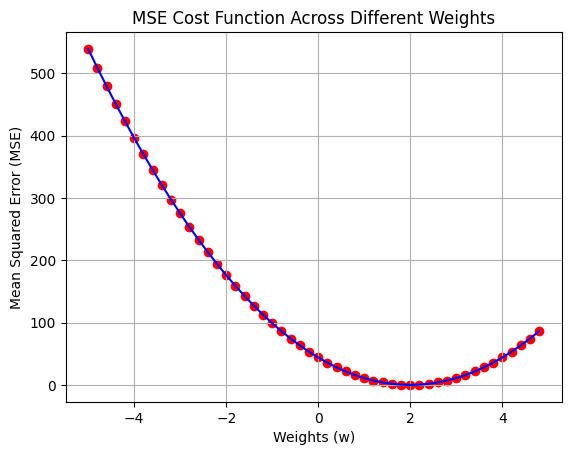

In [123]:
# Now let's visualize weights vs cost
plt.plot(weights_, mse_, color='blue')
plt.scatter(weights_, mse_, color='red')
plt.xlabel('Weights (w)')
plt.ylabel('Mean Squared Error (MSE)')
plt.title('MSE Cost Function Across Different Weights')
plt.grid(True)
plt.show()

In [124]:
def gradient_descent(w,b,alpha,epochs,h):

    print("Starting Numerical Gradient Descent...\n")

    for epoch in range(epochs):
        # 1. Get current base MSE cost
        _, _, current_mse = train_lr(X, y, w, b)
        
        # 2. Approximate slope for weight (w)
        _, _, mse_w_nudged = train_lr(X, y, w + h, b)
        slope_w = (mse_w_nudged - current_mse) / h
        
        # 3. Approximate slope for bias (b)
        _, _, mse_b_nudged = train_lr(X, y, w, b + h)
        slope_b = (mse_b_nudged - current_mse) / h
        
        # 4. Update parameters against the gradient
        w = w - (alpha * slope_w)
        b = b - (alpha * slope_b)
        
        # Track progress every 10 steps
        if epoch % 10 == 0 or epoch == epochs - 1:
            print(f"Epoch {epoch:2d} | MSE: {current_mse:7.4f} | w: {w:5.2f} | b: {b:5.2f}")

    print(f"\nFinal learned equation: y = {w:.2f}x + {b:.2f}")


In [125]:
# Now we do numerical Gradient Descent

# Initial parameters
w = -4.0  # Intentional terrible starting weight
b = 0.0   # Intentional terrible starting bias
alpha = 0.05  # Learning rate
epochs = 100
h = 0.00001  # Tiny step for calculating numerical gradient

gradient_descent(w,b,alpha,epochs,h)

Starting Numerical Gradient Descent...

Epoch  0 | MSE: 433.0000 | w:  2.90 | b:  1.90
Epoch 10 | MSE:  0.0489 | w:  1.86 | b:  1.51
Epoch 20 | MSE:  0.0348 | w:  1.88 | b:  1.43
Epoch 30 | MSE:  0.0247 | w:  1.90 | b:  1.36
Epoch 40 | MSE:  0.0176 | w:  1.92 | b:  1.31
Epoch 50 | MSE:  0.0125 | w:  1.93 | b:  1.26
Epoch 60 | MSE:  0.0089 | w:  1.94 | b:  1.22
Epoch 70 | MSE:  0.0063 | w:  1.95 | b:  1.18
Epoch 80 | MSE:  0.0045 | w:  1.96 | b:  1.15
Epoch 90 | MSE:  0.0032 | w:  1.96 | b:  1.13
Epoch 99 | MSE:  0.0024 | w:  1.97 | b:  1.11

Final learned equation: y = 1.97x + 1.11


In [126]:
# Now understanding what happens if the space we are searching using our linear assumption is not linear at all to begin with

In [127]:
# Imagine these values for parabola
""" 
| x   | y    |
| --- | ---- |
| 2.0 | 4.0  |
| 2.1 | 4.41 |
| 2.2 | 4.84 |
| 2.3 | 5.29 |

"""

' \n| x   | y    |\n| --- | ---- |\n| 2.0 | 4.0  |\n| 2.1 | 4.41 |\n| 2.2 | 4.84 |\n| 2.3 | 5.29 |\n\n'

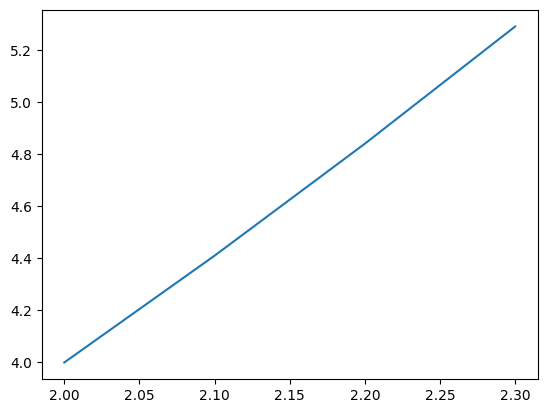

In [128]:
x = [2.0, 2.1, 2.2, 2.3]
y = [4.0, 4.41, 4.84, 5.29]
# Let's try plotting this values
plt.plot(x,y)
plt.show()

In [129]:
""" 
This is why the linearity assumption is really about the expected value

The assumption isn't : y=wx+b

            It's E[Y|X]=wx+b

where E[Y|X] means the expected (average) value of Y given X.

This is a much stronger statement.

It says:    "On average, after removing random noise, the relationship itself is linear."

That's the assumption statisticians are checking.

"""

' \nThis is why the linearity assumption is really about the expected value\n\nThe assumption isn\'t : y=wx+b\n\n            It\'s E[Y|X]=wx+b\n\nwhere E[Y|X] means the expected (average) value of Y given X.\n\nThis is a much stronger statement.\n\nIt says:    "On average, after removing random noise, the relationship itself is linear."\n\nThat\'s the assumption statisticians are checking.\n\n'

In [130]:
# So even though we predicted well today doesn't mean the underlying true relationship is linear too

In [131]:
# Now we will do an experiment on why a line will still act as a good approximator even for a true function : hyperbola given a small interval

In [132]:
x = np.random.uniform(-10,10,10) # X values in parabola
y = x**2 # y values for parabola

--- Training Complete ---
Optimised Equation : y = -0.5432x + 34.4179
Average MSE        : 870.9332
Average MAE        : 25.1918


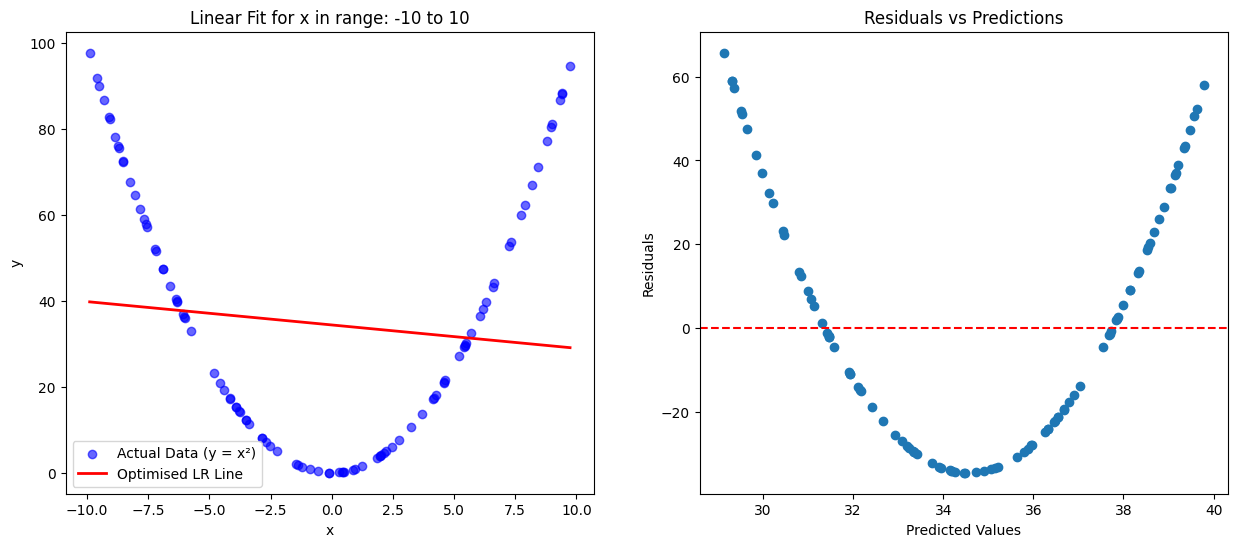

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def experiment(lower_limit, upper_limit, epochs=2000, lr=0.001):
    """
    Generates parabolic data, trains a Linear Regression model 
    using Gradient Descent, and visualises the results.
    """
    # 1. Generate synthetic dataset
    # Seed ensures reproducibility; remove if you want true randomness every run
    np.random.seed(42) 
    x = np.random.uniform(lower_limit, upper_limit, 100) # Increased to 100 points for stable training
    y = x**2 

    # 2. Actual Linear Regression Training via Gradient Descent
    def train_lr_gradient_descent(X, y, epochs, lr):
        # Initialise weights at zero
        w = 0.0
        b = 0.0
        n = len(X)
        
        for epoch in range(epochs):
            predictions = w * X + b
            
            # Calculate gradients (partial derivatives of Mean Squared Error)
            dw = (-2 / n) * np.sum(X * (y - predictions))
            db = (-2 / n) * np.sum(y - predictions)
            
            # Update parameters simultaneously
            w -= lr * dw
            b -= lr * db
            
        # Compute final optimized predictions and metrics
        final_predictions = w * X + b
        loss = y - final_predictions
        mae = np.mean(np.abs(loss))
        mse = np.mean(loss**2)
        
        return w, b, mae, mse, final_predictions

    # 3. Train the model
    w, b, mae, mse, predictions = train_lr_gradient_descent(x, y, epochs, lr)

    # 4. Print optimised metrics
    print(f"--- Training Complete ---")
    print(f"Optimised Equation : y = {w:.4f}x + {b:.4f}")
    print(f"Average MSE        : {mse:.4f}")
    print(f"Average MAE        : {mae:.4f}")

    # 5. Visualisation
    plt.figure(figsize=(15, 6))
    
    # Left Subplot: Fitted Straight Line vs Parabolic Data
    plt.subplot(121)
    plt.title(f'Linear Fit for x in range: {lower_limit} to {upper_limit}')
    plt.scatter(x, y, color='blue', alpha=0.6, label='Actual Data (y = x²)')
    plt.xlabel('x')
    plt.ylabel('y')
    
    # Sort x to prevent zigzag lines in the plot
    sort_idx = np.argsort(x)
    plt.plot(x[sort_idx], predictions[sort_idx], color='red', linewidth=2, label='Optimised LR Line')
    plt.legend()

    # Right Subplot: Predicted vs Actual (Residual Structure)
    plt.subplot(122)
    plt.title("Residuals vs Predictions")

    residuals = y - predictions

    plt.scatter(predictions, residuals)

    plt.axhline(
        y=0,
        color='red',
        linestyle='--'
    )

    plt.xlabel("Predicted Values")
    plt.ylabel("Residuals")

# Run the updated experiment
experiment(-10, 10)


In [13]:
class GDR:
    def __init__(self, m, b, learning_rate, epochs, lower_limit, upper_limit):
        self.m = m
        self.b = b
        self.l = learning_rate
        self.epochs = epochs
        self.lower_limit = lower_limit
        self.upper_limit = upper_limit
        
        # Automatically generate and store data upon instantiation
        self.X, self.y = self.generate_data()

    def generate_data(self):
        np.random.seed(42) 
        X = np.random.uniform(self.lower_limit, self.upper_limit, 100) 
        y = X**2  
        return X, y

    def fit(self):
        n = len(self.X)
        X_flat = self.X.ravel()
        
        for i in range(self.epochs):
            loss_slope_b = -2 * (np.sum(self.y - (self.m * X_flat) - self.b)) / n 
            step_size_b = loss_slope_b * self.l
            
            loss_slope_m = -2 * (np.sum((self.y - (self.m * X_flat) - self.b) * X_flat)) / n 
            step_size_m = loss_slope_m * self.l

            # Finally update parameters
            self.b -= step_size_b
            self.m -= step_size_m
    
    def predict(self):
        return self.m * self.X + self.b
    
    def residuals(self):
        return self.y - self.predict()
    
    def mae(self):
        return np.mean(np.abs(self.residuals()))
    
    def mse(self):
        return np.mean(self.residuals()**2)

    def get_metrics(self):
        print(f"Optimised Equation : y = {self.m:.4f}x + {self.b:.4f}")
        print(f"Average MSE        : {self.mse():.4f}")
        print(f"Average MAE        : {self.mae():.4f}")

    def plot_fit(self):
        predictions = self.predict()
        
        plt.figure(figsize=(8, 5))
        plt.title(f'Linear Fit for x in range: {self.lower_limit} to {self.upper_limit}')
        plt.scatter(self.X, self.y, color='blue', alpha=0.6, label='Actual Data (y = x²)')
        plt.xlabel('x')
        plt.ylabel('y')

        sort_idx = np.argsort(self.X)
        plt.plot(self.X[sort_idx], predictions[sort_idx], color='red', linewidth=2, label='Optimised LR Line')
        plt.legend()
        plt.show()

    def plot_residuals_vs_prediction(self):
        predictions = self.predict()
        residuals = self.residuals()

        plt.figure(figsize=(8, 5))
        plt.title("Residuals vs Predictions")
        plt.scatter(predictions, residuals, color='purple', alpha=0.6)
        plt.axhline(y=0, color='red', linestyle='--')
        plt.xlabel("Predicted Values")
        plt.ylabel("Residuals")
        plt.show()

    def plot_residuals_vs_x(self):
        residuals = self.residuals()

        plt.figure(figsize=(8, 5))
        plt.title(f' Residuals vs X plot : {self.lower_limit} to {self.upper_limit}')
        plt.scatter(self.X,residuals,color='green', alpha=0.6)
        plt.xlabel("X")
        plt.ylabel("Residual")
        plt.axhline(
            y=0,
            color='red',
            linestyle='--'
        )
        plt.show()


Optimised Equation : y = -0.5317x + 35.0846
Average MSE        : 870.4931
Average MAE        : 25.2768


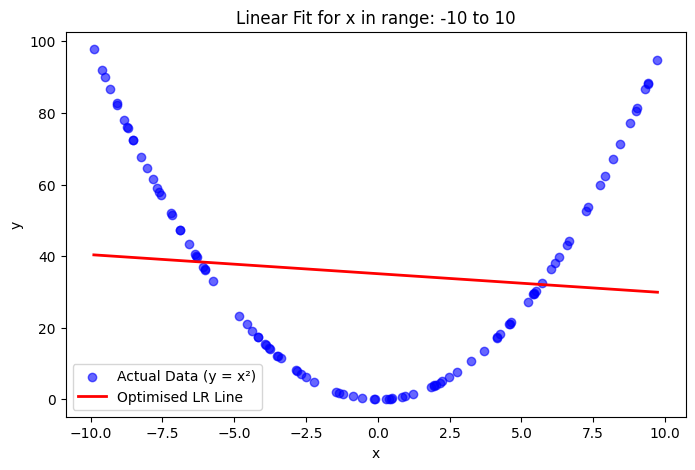

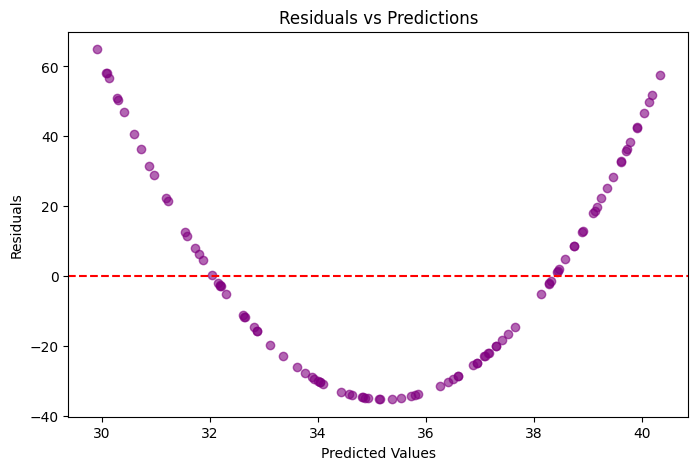

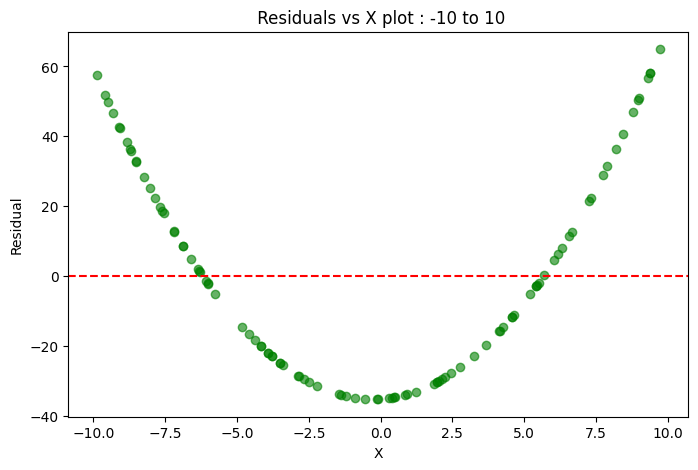

In [14]:
# Experiment 1
model = GDR(m=0.0, b=0.0, learning_rate=0.01, epochs=1000, lower_limit=-10, upper_limit=10) 

model.fit()
model.get_metrics()
model.plot_fit()
model.plot_residuals_vs_prediction()
model.plot_residuals_vs_x()